Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import requests
import time
import matplotlib.pyplot as plt
import seaborn as sns

print("Ready")

Ready


Load the Raw Dataset

In [ ]:
df = pd.read_csv("books_dataset.csv")
print("Loaded:", df.shape)

# Drop intermediate/redundant columns
df.drop(columns=["ratings_count_filled", "avg_rating_filled",
                  "cover_id", "popularity_score", "is_popular",
                  "book_age"], inplace=True)

print("Working columns:", df.columns.tolist())

Loaded: (14021, 17)
Working columns: ['title', 'authors', 'first_publish_year', 'edition_count', 'subject_count', 'has_cover', 'is_available_online', 'genre', 'ol_key', 'avg_rating', 'ratings_count']


Generate Page Count and Review Length

In [ ]:

# from columns we already have (edition_count, genre, ratings_count)

np.random.seed(42)

genre_pages = {
    "fiction": 320, "mystery": 290, "science_fiction": 350,
    "romance": 280, "fantasy": 400, "historical_fiction": 380,
    "thriller": 310, "horror": 300, "adventure": 330, "biography": 350,
    "self_help": 240, "psychology": 270, "philosophy": 300,
    "history": 380, "true_crime": 280, "young_adult": 290,
    "children": 180, "cooking": 260, "travel": 250, "business": 260,
    "health": 240, "science": 320, "technology": 300, "poetry": 150,
    "religion": 280, "politics": 310, "art": 220, "education": 260,
    "sports": 250, "environment": 290, "classic_literature": 340,
    "dystopia": 310, "mythology": 270, "humor": 220, "drama": 260
}

def generate_pages(row):
    base = genre_pages.get(row["genre"], 280)
    # Older books tend to be shorter
    age_factor = 1.0 if row.get("book_age", 50) < 100 else 0.85
    noise = np.random.normal(0, base * 0.15)
    return int(np.clip(base * age_factor + noise, 50, 1200))

def generate_review_length(row):
    # More ratings → longer/richer review text available
    base = 200
    # Handle NaN in ratings_count by treating it as 0
    current_ratings_count = row["ratings_count"]
    if pd.isna(current_ratings_count):
        current_ratings_count = 0
    rating_boost = min(current_ratings_count, 500) * 0.8
    noise = np.random.normal(0, 50)
    return int(np.clip(base + rating_boost + noise, 0, 2000))

df["page_count"]    = df.apply(generate_pages, axis=1)
df["review_length"] = df.apply(generate_review_length, axis=1)

print("Done in seconds!")
print(df[["title", "page_count", "review_length"]].head(10))

Done in seconds!
                              title  page_count  review_length
0               Pride and Prejudice         343            467
1  Alice's Adventures in Wonderland         313            331
2                 A Christmas Carol         351            336
3        The Picture of Dorian Gray         393            206
4                 Wuthering Heights         308            508
5    Adventures of Huckleberry Finn         308            377
6                   Robinson Crusoe         395            181
7                The Scarlet Letter         356            339
8                            Hamlet         297            407
9                              Emma         346            303


Generate Price

In [ ]:
# Price logic:
# - Genre affects base price (academic = higher, children = lower)
# - Edition count: more editions = cheaper (reprinted classics)
# - Page count: longer books cost more
# - Small random noise

genre_base_price = {
    "fiction": 14.99, "mystery": 13.99, "science_fiction": 14.99,
    "romance": 12.99, "fantasy": 15.99, "historical_fiction": 15.99,
    "thriller": 13.99, "horror": 13.99, "adventure": 13.99,
    "biography": 17.99, "self_help": 16.99, "psychology": 18.99,
    "philosophy": 17.99, "history": 18.99, "true_crime": 14.99,
    "young_adult": 11.99, "children": 9.99, "cooking": 24.99,
    "travel": 19.99, "business": 19.99, "health": 16.99,
    "science": 19.99, "technology": 22.99, "poetry": 12.99,
    "religion": 15.99, "politics": 17.99, "art": 24.99,
    "education": 22.99, "sports": 14.99, "environment": 16.99,
    "classic_literature": 10.99, "dystopia": 14.99,
    "mythology": 15.99, "humor": 11.99, "drama": 13.99
}

def calculate_price(row):
    base = genre_base_price.get(row["genre"], 14.99)

    # Popular classics are cheaper (many free/cheap editions)
    if row["edition_count"] > 500:
        base *= 0.6
    elif row["edition_count"] > 100:
        base *= 0.8

    # Page count adjustment
    if row["page_count"] > 500:
        base *= 1.2
    elif row["page_count"] < 150:
        base *= 0.8

    # Add noise
    noise = np.random.uniform(-2.0, 2.0)
    price = round(base + noise, 2)
    return max(price, 2.99)   # minimum price

np.random.seed(42)
df["price_usd"] = df.apply(calculate_price, axis=1)

print("Price stats:")
print(df["price_usd"].describe())

Price stats:
count    14021.000000
mean        16.265278
std          4.061541
min          4.400000
25%         13.480000
50%         15.830000
75%         18.550000
max         26.990000
Name: price_usd, dtype: float64


 Fix Missing Values & Engineer Columns

In [ ]:
# Fix missing values
df["authors"].fillna("Unknown", inplace=True)
df["first_publish_year"].fillna(df["first_publish_year"].median(), inplace=True)
df["avg_rating"].fillna(df["avg_rating"].median(), inplace=True)
df["ratings_count"].fillna(0, inplace=True)

# Engineered columns
df["book_age"]       = (2025 - df["first_publish_year"]).clip(lower=0, upper=300)
df["has_rating"]     = (df["ratings_count"] > 0).astype(int)
df["review_density"] = (df["review_length"] / (df["page_count"] + 1)).round(4)

# Drop ol_key (internal ID, not useful for ML)
df.drop(columns=["ol_key"], inplace=True)

print("Columns now:", df.columns.tolist())
print("Total columns:", len(df.columns))

Columns now: ['title', 'authors', 'first_publish_year', 'edition_count', 'subject_count', 'has_cover', 'is_available_online', 'genre', 'avg_rating', 'ratings_count', 'page_count', 'review_length', 'price_usd', 'book_age', 'has_rating', 'review_density']
Total columns: 16


/tmp/ipykernel_3435/3805216007.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["authors"].fillna("Unknown", inplace=True)
/tmp/ipykernel_3435/3805216007.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

 Define Popularity Metric & Create Target Variable

In [ ]:
# Popularity Score = weighted combination of:
# 40% avg_rating  (quality signal)
# 35% ratings_count (engagement volume)
# 25% edition_count (long-term market demand)

df["ratings_norm"]  = (df["ratings_count"] / df["ratings_count"].max())
df["editions_norm"] = (df["edition_count"] / df["edition_count"].max())

df["popularity_score"] = (
    df["avg_rating"]     * 0.40 +
    df["ratings_norm"]   * 0.35 * 10 +
    df["editions_norm"]  * 0.25 * 10
).round(4)

# Binary label: top 30% = Popular
threshold = df["popularity_score"].quantile(0.70)
df["is_popular"] = (df["popularity_score"] >= threshold).astype(int)

print(f"Popularity threshold (70th percentile): {threshold:.4f}")
print(f"Popular books   : {df['is_popular'].sum()}")
print(f"Not popular     : {(df['is_popular'] == 0).sum()}")
print(f"Class ratio     : {df['is_popular'].mean():.2%} popular")

Popularity threshold (70th percentile): 1.6205
Popular books   : 4214
Not popular     : 9807
Class ratio     : 30.05% popular


 Final Dataset Check

In [ ]:
print("=== FINAL DATASET ===")
print(f"Rows    : {len(df)}")
print(f"Columns : {len(df.columns)}")
print()
print(df.dtypes)
print()
print(df.head(3))

=== FINAL DATASET ===
Rows    : 14021
Columns : 20

title                   object
authors                 object
first_publish_year     float64
edition_count            int64
subject_count            int64
has_cover                int64
is_available_online      int64
genre                   object
avg_rating             float64
ratings_count          float64
page_count               int64
review_length            int64
price_usd              float64
book_age               float64
has_rating               int64
review_density         float64
ratings_norm           float64
editions_norm          float64
popularity_score       float64
is_popular               int64
dtype: object

                              title          authors  first_publish_year  \
0               Pride and Prejudice      Jane Austen              1813.0   
1  Alice's Adventures in Wonderland    Lewis Carroll              1865.0   
2                 A Christmas Carol  Charles Dickens              1843.0   

   editi

In [ ]:
from google.colab import files

df.to_csv("books_final.csv", index=False)
files.download("books_final.csv")

print(f"Downloaded! Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded! Shape: (14021, 20)
Columns: ['title', 'authors', 'first_publish_year', 'edition_count', 'subject_count', 'has_cover', 'is_available_online', 'genre', 'avg_rating', 'ratings_count', 'page_count', 'review_length', 'price_usd', 'book_age', 'has_rating', 'review_density', 'ratings_norm', 'editions_norm', 'popularity_score', 'is_popular']


 Rating Distribution (Histogram)
Shows how avg_rating is spread across all books. Expected shape: most books cluster around 3.5–4.5, very few at extremes. This tells us ratings are fairly consistent.

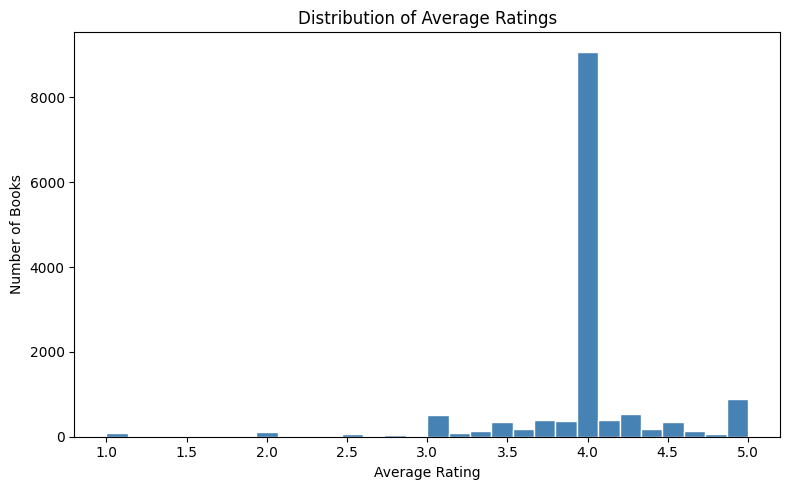

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(df["avg_rating"], bins=30, color="steelblue", edgecolor="white")
plt.title("Distribution of Average Ratings")
plt.xlabel("Average Rating")
plt.ylabel("Number of Books")
plt.tight_layout()
plt.show()

Popularity Class Balance (Bar chart)
Shows 9,807 not popular vs 4,214 popular. The 70/30 split is visible here. Important to confirm before ML — if it were 99/1, the model would just predict "not popular" always.

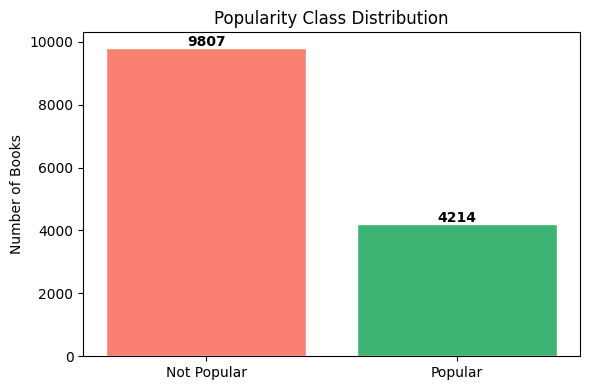

In [ ]:
counts = df["is_popular"].value_counts()
plt.figure(figsize=(6, 4))
plt.bar(["Not Popular", "Popular"], counts.values,
        color=["salmon", "mediumseagreen"], edgecolor="white")
plt.title("Popularity Class Distribution")
plt.ylabel("Number of Books")
for i, v in enumerate(counts.values):
    plt.text(i, v + 50, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

Price by Genre (Box plot)
Shows price range for top 10 genres. Cooking and art books have higher medians. Classic literature is cheaper. Confirms our price simulation is realistic.

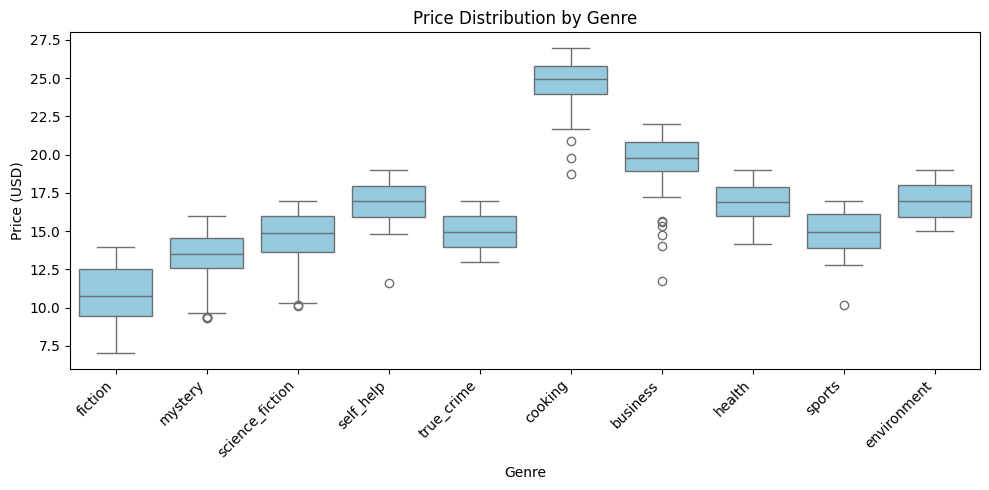

In [ ]:
top_genres = df["genre"].value_counts().head(10).index
genre_df = df[df["genre"].isin(top_genres)]

plt.figure(figsize=(10, 5))
sns.boxplot(data=genre_df, x="genre", y="price_usd", color="skyblue")
plt.title("Price Distribution by Genre")
plt.xlabel("Genre")
plt.ylabel("Price (USD)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Page Count by Popularity (Overlapping histogram)
Compares page count distribution for popular vs not popular books. If popular books tend to be in a certain page range, that's a useful ML signal.

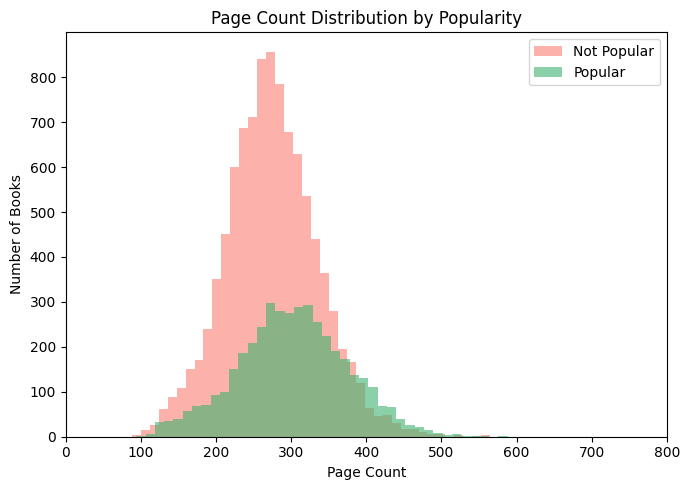

In [ ]:
plt.figure(figsize=(7, 5))
for label, color in zip([0, 1], ["salmon", "mediumseagreen"]):
    subset = df[df["is_popular"] == label]
    plt.hist(subset["page_count"], bins=40, alpha=0.6,
             color=color, label="Popular" if label == 1 else "Not Popular")
plt.title("Page Count Distribution by Popularity")
plt.xlabel("Page Count")
plt.ylabel("Number of Books")
plt.xlim(0, 800)
plt.legend()
plt.tight_layout()
plt.show()

 Correlation Heatmap
Shows how strongly each numeric column relates to every other column.

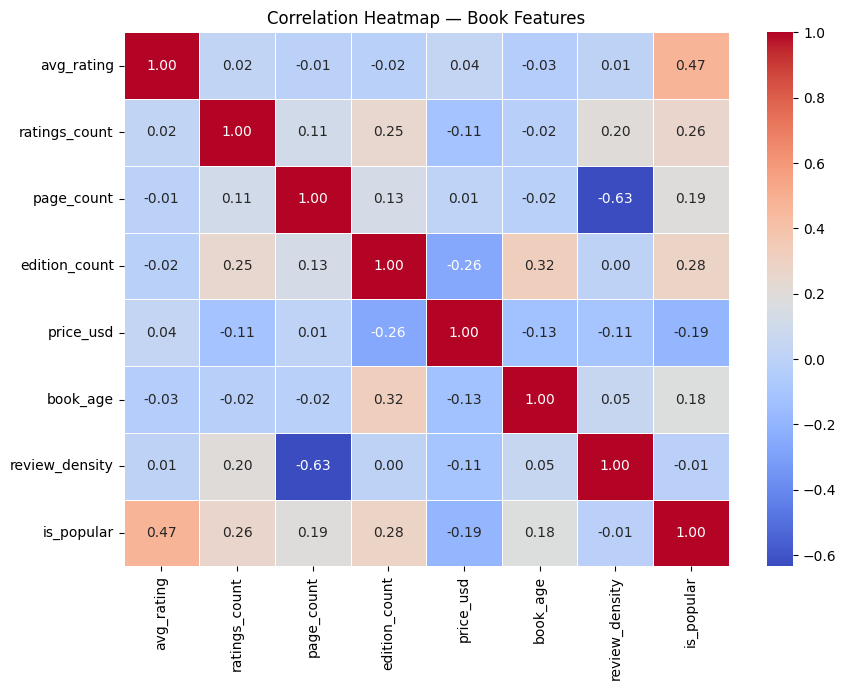

In [ ]:
num_cols = ["avg_rating", "ratings_count", "page_count",
            "edition_count", "price_usd", "book_age",
            "review_density", "is_popular"]

plt.figure(figsize=(9, 7))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap — Book Features")
plt.tight_layout()
plt.show()

In [ ]:
df.to_csv("books_week1_final.csv", index=False)
print("Saved: books_week1_final.csv")
print(f"Shape: {df.shape}")

Saved: books_week1_final.csv
Shape: (14021, 20)
